# Cosmological Parameter Inference with Pantheon+SH0ES
**Model**: Flat ΛCDM with the Tripp (1998) distance estimator (Eq. 1 of Brout et al. 2022)

$$\mu_{\rm obs} = m_B + \alpha x_1 - \beta c - M - \delta_{\rm bias} + \delta_{\rm host}$$

We set $\delta_{\rm bias} = \delta_{\rm host} = 0$ and infer $(H_0, \Omega_m, \alpha, \beta, M)$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import corner
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

## 1. Load data

In [2]:
df = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')

# Exclude Cepheid calibrators (very low-z, absolute distance anchors)
# and keep only Hubble-flow SNe
mask = (df['zHD'] > 0.01) & (df['IS_CALIBRATOR'] == 0)
df   = df[mask].reset_index(drop=True)

# Observables from SALT2 fit (Tripp estimator inputs)
z    = df['zHD'].values          # Hubble-diagram redshift
mB   = df['mB'].values           # uncorrected peak magnitude
x1   = df['x1'].values           # stretch
c    = df['c'].values            # color
mB_err = df['mBERR'].values      # uncertainty on mB
x1_err = df['x1ERR'].values
c_err  = df['cERR'].values

# For plotting only (diagonal errors, not used in the likelihood fit)
mu_plot     = df['MU_SH0ES'].values
mu_plot_err = df['MU_SH0ES_ERR_DIAG'].values

print(f'SNe in fit: {len(z)}')
print(f'Redshift range: {z.min():.4f} – {z.max():.4f}')

SNe in fit: 1580
Redshift range: 0.0102 – 2.2614


<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_27281/2017306566.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')


## 2. Model

**Observed distance modulus** (Tripp estimator, $\delta$s = 0):
$$\mu_{\rm obs}(\alpha,\beta,M) = m_B + \alpha x_1 - \beta c - M$$

**Theoretical distance modulus** (flat ΛCDM):
$$\mu_{\rm th}(z, H_0, \Omega_m) = 5\log_{10}\left(d_L(z)/\text{Mpc}\right) + 25$$

**Statistical uncertainty** on $\mu_{\rm obs}$ (error propagation from SALT2):
$$\sigma_{\mu}^2 = \sigma_{m_B}^2 + \alpha^2\sigma_{x_1}^2 + \beta^2\sigma_c^2$$

(Cross-terms from the full covariance matrix are ignored here for simplicity.)

In [3]:
def mu_theory(z, H0, Om0):
    """Theoretical distance modulus for flat ΛCDM via astropy."""
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    dL    = cosmo.luminosity_distance(z).to(u.Mpc).value
    return 5.0 * np.log10(dL) + 25.0

def mu_obs(mB, x1, c, alpha, beta, M):
    """Observed distance modulus from Tripp estimator (Eq. 1, deltas=0)."""
    delta_bias = 0.0   # set to 0; could use df['BIAS_...'] column if available
    delta_host = 0.0   # set to 0; could use host-mass step function (Eq. 2)
    return mB + alpha * x1 - beta * c - M - delta_bias + delta_host

def sigma_mu(alpha, beta, mB_err, x1_err, c_err):
    """Statistical uncertainty on mu_obs from error propagation (diagonal only)."""
    return np.sqrt(mB_err**2 + (alpha * x1_err)**2 + (beta * c_err)**2)

## 3. Sanity check — model curves vs data

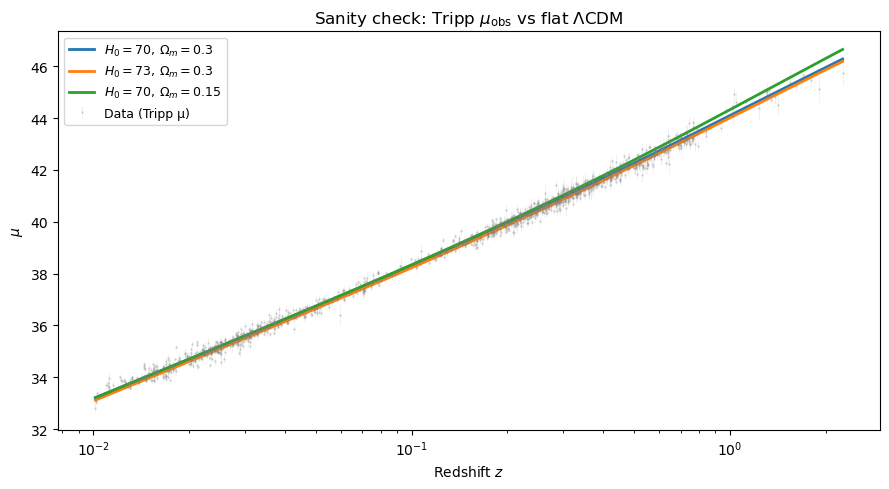

In [4]:
# Typical SALT2 nuisance values from the literature
alpha0, beta0, M0 = 0.15, 3.1, -19.3

mu_obs_check = mu_obs(mB, x1, c, alpha0, beta0, M0)
sig_check    = sigma_mu(alpha0, beta0, mB_err, x1_err, c_err)

z_th = np.geomspace(z.min(), z.max(), 500)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(z, mu_obs_check, yerr=sig_check, fmt='.', color='gray',
            alpha=0.2, ms=2, elinewidth=0.4, capsize=0, label='Data (Tripp μ)')
for H0, Om0, lbl, col in [
    (70, 0.3,  r'$H_0=70,\,\Omega_m=0.3$',  'C0'),
    (73, 0.3,  r'$H_0=73,\,\Omega_m=0.3$',  'C1'),
    (70, 0.15, r'$H_0=70,\,\Omega_m=0.15$', 'C2'),
]:
    ax.plot(z_th, mu_theory(z_th, H0, Om0), lw=2, color=col, label=lbl)
ax.set_xscale('log')
ax.set_xlabel('Redshift $z$'); ax.set_ylabel(r'$\mu$')
ax.set_title(r'Sanity check: Tripp $\mu_{\rm obs}$ vs flat $\Lambda$CDM')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()